# 【dry surface methodによる接触角の計算】

### 以下の図に示す、始状態から終状態までの自由エネルギー差を計算して、接触角を計算します.

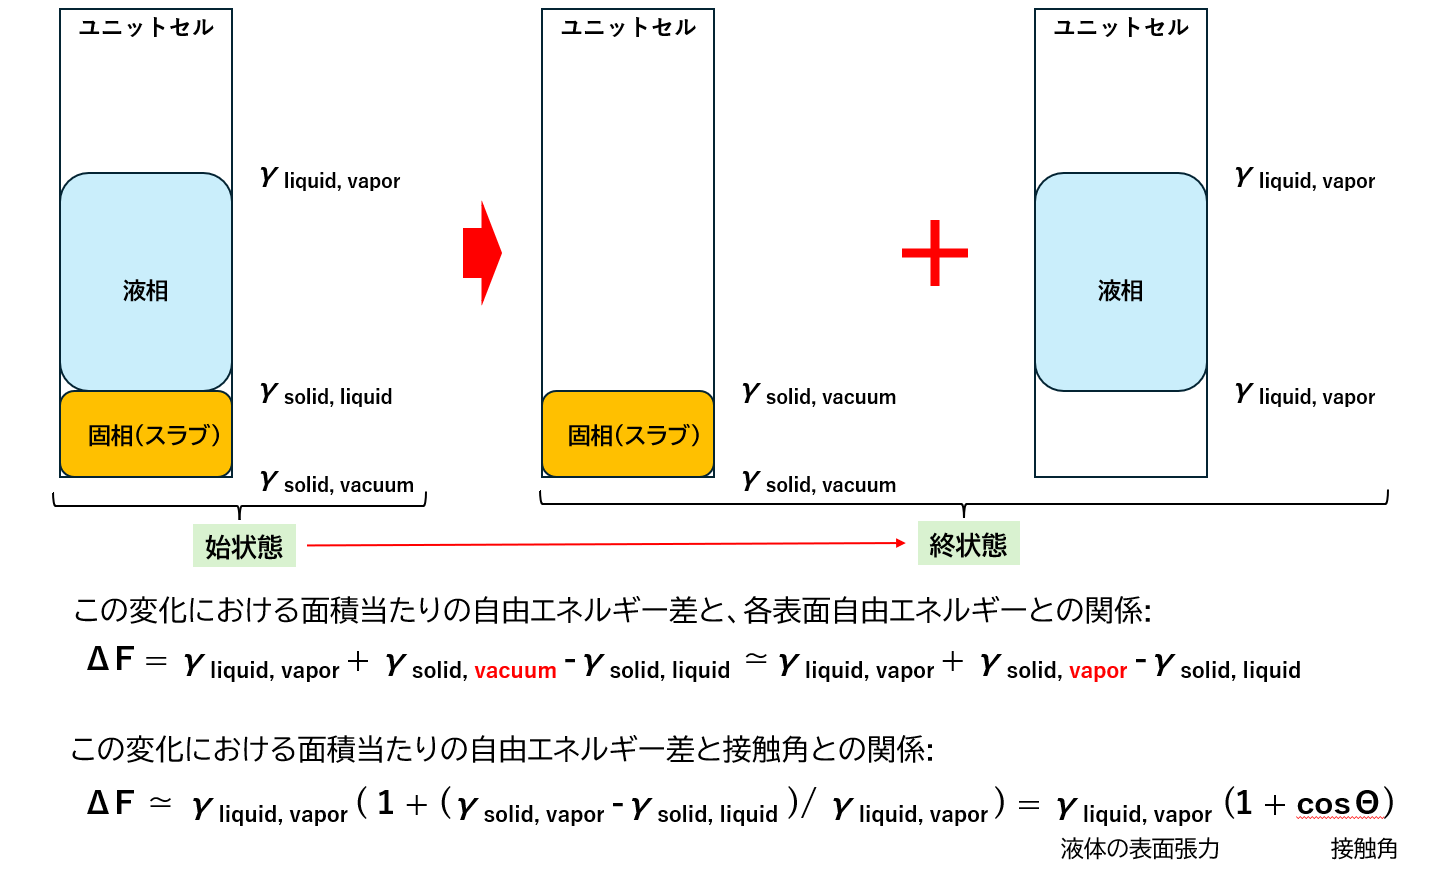

## 【自由エネルギー摂動法による、自由エネルギー差 ΔF の計算の流れ】
### (1) 始状態(λ=0)から中間状態を経て終状態(λ=1)に至るまで(λ=0.00, λ=0.05, ..., λ=1.00)の、初期構造インプットファイルを生成します.
### [中間状態(λ)]= ( 1 - λ)×[始状態] + λ×[終状態] として各中間状態が表現されています.
### 始状態から終状態へは、100 ps かけてゆっくり変化させていきます. ゆっくりと変化させることにより、各中間状態が平衡状態となっていることを保証します.  
   

### (2) 各状態（始状態、いくつかの中間状態、終状態）の平衡状態での構造サンプリング
### (3) ステップ(2)でサンプリングした構造からの、自由エネルギー摂動法による自由エネルギー( ΔF )計算
### 本ノートブックでの計算の後、別ノートブックで  
### (4) 液体の表面張力( γ<sub>liquid, vapor</sub> )の計算
### を行い、その結果より接触角を予測します.
### なお、(4)はPBE_PLUS_D3モードの場合、水 375 Kで88 mN/m となりました。  
### 本ノートブックでは表面張力の計算を省略しておりますので、詳細に関しては表面張力の計算のノートブックをご参照ください。
<br>

## 【インプットの初期構造ファイル total.xyz, slab.xyz, liquid.xyz について】
### total.xyz での原子の並び順は、前半にスラブ原子、後半に液相原子となっています.
### また、liquid.xyz, slab.xyz の原子の並び順は total.xyz と同じにしてください.
<br>

### 【自由エネルギー解析に必要な環境の設定】

In [1]:
#---------------------------------------------
# Atoms_dry_surface クラス
#---------------------------------------------
from ase import Atoms
import numpy as np
from joblib import delayed, Parallel


class Atoms_dry_surface(Atoms):
    '''
    ASEのAtomsクラスをオーバーライドして、
    固相と液相の全系(始状態)、固相のみと液相のみで別々にした系(終状態)、について、始状態と終状態をパラメータλで指定した割合で混合した中間状態の系について、エネルギーと力を計算します。
    '''
    

    def __init__(self, atoms_total, atoms_slab, atoms_liquid, coupling_parameter):
        super().__init__(
            symbols=atoms_total.symbols,
            positions=atoms_total.get_positions(),
            cell=atoms_total.cell,
            pbc=atoms_total.pbc,
            momenta = atoms_total.get_momenta()
        )

        if not isinstance(atoms_total, Atoms) or not isinstance(atoms_liquid, Atoms) or not isinstance(atoms_slab, Atoms):
            raise TypeError("atoms_A and atoms_B must be instances of the Atoms class.")
        
        self.atoms_total = atoms_total
        self.atoms_slab = atoms_slab
        self.atoms_liquid = atoms_liquid
        self.coupling_parameter = coupling_parameter

        self.set_constraint(atoms_total.constraints)
        natom_total = len(atoms_total)
        self.slab_mask = [False]*natom_total
        self.liquid_mask = [True]*natom_total
        for i in range(len(atoms_slab)):
            self.slab_mask[i] = True
            self.liquid_mask[i] = False
        
        # atomsのセルが一致することを確認
        cell_total = self.atoms_total.cell
        cell_slab   = self.atoms_slab.cell
        cell_liquid = self.atoms_liquid.cell
        if not np.array_equal(cell_total, cell_liquid) or not np.array_equal(cell_total, cell_slab ):
            raise ValueError("atoms_A and atoms_B must have the same cell and positions.")
        # atoms.calcに別々のcalculatorがセットされていることを確認（並列化に必要）
        self.parallel_calculation = Parallel(n_jobs=3, verbose=0, backend='threading')

        

    def get_potential_energy(self, **kwargs):
        """
        結合パラメーターに基づき、3つのAtomsインスタンスのポテンシャルエネルギーを組み合わせて計算します。
        
        このメソッドは、以下のFEP計算ロジックを実装します:
        E_fep = (1 - λ) * E_A + λ * E_B
        """
        positions_total = self.get_positions()
        positions_slab = positions_total[self.slab_mask]
        positions_liquid = positions_total[self.liquid_mask]
            
        self.atoms_total.set_positions(positions_total)
        self.atoms_slab.set_positions(positions_slab)
        self.atoms_liquid.set_positions(positions_liquid)

        tasks = [
            delayed(self.atoms_total.get_potential_energy)(**kwargs), 
            delayed(self.atoms_slab.get_potential_energy)(**kwargs),
            delayed(self.atoms_liquid.get_potential_energy)(**kwargs) 
        ]
            
        results = self.parallel_calculation(tasks)
        energy_total, energy_slab, energy_liquid = results
        
        # energy_total = self.atoms_total.get_potential_energy(**kwargs)
        # energy_liquid = self.atoms_liquid.get_potential_energy(**kwargs)
        # energy_slab = self.atoms_slab.get_potential_energy(**kwargs)
        
        # 結合パラメーターを使ってFEPエネルギーを計算
        energy = (1 - self.coupling_parameter) * energy_total + self.coupling_parameter * (energy_liquid + energy_slab)
        
        return energy
        
    def get_stress(self, **kwargs):
        
        # 今回の計算で get_stress は利用していません
        
        positions_total = self.get_positions()
        positions_slab = positions_total[self.slab_mask]
        positions_liquid = positions_total[self.liquid_mask]
            
        self.atoms_total.set_positions(positions_total)
        self.atoms_slab.set_positions(positions_slab)
        self.atoms_liquid.set_positions(positions_liquid)
        
        stress_total  = self.atoms_total.get_stress( **kwargs)
        stress_slab   = self.atoms_slab.get_stress( **kwargs)
        stress_liquid = self.atoms_liquid.get_stress( **kwargs)
        stress_liquid_slab = np.concatenate([stress_slab, stress_liquid], axis=0)
        
        # 結合パラメーターを使ってFEPエネルギーを計算
        stress = (1 - self.coupling_parameter) * stress_total #+ self.coupling_parameter * stress_liquid_slab
        
        return stress
 
        

    def get_forces(self, apply_constraint=True, **kwargs):
        """
        結合パラメーターに基づき、3つのAtomsインスタンスの力を組み合わせて計算します。
        
        このメソッドは、以下のFEP計算ロジックを実装します:
        F_fep = (1 - λ) * F_A + λ * F_B
        """
        
        positions_total = self.get_positions()
        positions_slab = positions_total[self.slab_mask]
        positions_liquid = positions_total[self.liquid_mask]
            
        self.atoms_total.set_positions(positions_total)
        self.atoms_slab.set_positions(positions_slab)
        self.atoms_liquid.set_positions(positions_liquid)

        
        tasks = [
            delayed(self.atoms_total.get_forces)(apply_constraint=apply_constraint, **kwargs),
            delayed(self.atoms_slab.get_forces)(apply_constraint=apply_constraint, **kwargs),
            delayed(self.atoms_liquid.get_forces)(apply_constraint=apply_constraint, **kwargs)
        ]
        
        results = self.parallel_calculation(tasks)
        forces_total, forces_slab, forces_liquid = results
        
        # atoms_Aとatoms_Bの力を個別に取得
        # forces_total  = self.atoms_total.get_forces(apply_constraint=apply_constraint, **kwargs)
        # forces_liquid = self.atoms_liquid.get_forces(apply_constraint=apply_constraint, **kwargs)
        # forces_slab   = self.atoms_slab.get_forces(apply_constraint=apply_constraint, **kwargs)
        forces_liquid_slab = np.concatenate([forces_slab, forces_liquid], axis=0)
        
        
        # 結合パラメーターを使ってFEPの力を計算
        forces = (1.0 - self.coupling_parameter) * forces_total + self.coupling_parameter * forces_liquid_slab
        
        return forces



import pathlib
from ase import units
from ase.io import read, write
from ase.constraints import Hookean, FixAtoms
from ase.md.langevin import Langevin
from ase.md import MDLogger
from pfp_api_client.pfp.estimator import Estimator, EstimatorCalcMode
from pfp_api_client.pfp.calculators.ase_calculator import ASECalculator


#-----------------------------------------------------------------------------------
# Atoms_dry_surface_step1 始状態から中間状態を経由し終状態まで、各状態の初期状態を生成する
#-----------------------------------------------------------------------------------

def dry_surface_method_step1(atoms_total_in, atoms_slab_in, atoms_liquid_in, temperature, fix_z, wall_z, wall_k=5.0):
  """
  始状態から終状態までの中間状態を生成し、それぞれの状態について、初期構造ファイルを保存します。
  wall_z, wall_k は液相の原子が固相の原子に重なってしまうことを防ぐための壁ポテンシャルのパラメータです。
  wall_z の値は適用する系にあわせて適宜変更してください。
  """

    
    
  atoms_total = atoms_total_in.copy()
  atoms_slab = atoms_slab_in.copy()
  atoms_liquid = atoms_liquid_in.copy()
    
  num_slab = len(atoms_slab)
    
  # 計算に必要な拘束条件などを設定します
  # 1. 蒸発した水を跳ね返す壁ポテンシャル ( z = 100 Å の位置)
  # 2. スラブ下部の原子位置の固定
  # 3. 液相の固相へのめり込み防止のための壁ポテンシャル ( z = wall_z の位置)
    
  # for total system
  zpositions = atoms_total.get_positions()[:, 2]
  indices_to_fix = np.where(zpositions <= fix_z)[0]
  constraints = []
  for i, (zpos, atom) in enumerate(zip(zpositions, atoms_total)):
    if (atom.symbol not in [ 'H']) and (i > num_slab):
      constraints.append(Hookean(a1=i, a2=(0., 0., +1., -100), k=0.5))
    if i > num_slab:
      constraints.append(Hookean(a1=i, a2=(0., 0., -1., wall_z), k=wall_k))
  c = FixAtoms(indices=indices_to_fix)
  constraints.append(c)
  atoms_total.set_constraint(constraints)
    
    
  # for slab system
  zpositions = atoms_slab.get_positions()[:, 2]
  indices_to_fix = np.where(zpositions <= fix_z)[0]
  constraints = []
  c = FixAtoms(indices=indices_to_fix)
  constraints.append(c)
  atoms_slab.set_constraint(constraints)
 
    
  # constraint to liquid
  constraints = []
  for i, atom in enumerate(atoms_liquid):
    if atom.symbol not in ['H'] :
       constraints.append(Hookean(a1=i, a2=(0., 0., +1., -100), k=0.5))
    constraints.append(Hookean(a1=i, a2=(0., 0., -1., wall_z), k=wall_k))
  atoms_liquid.set_constraint(constraints)


    
  estimator = Estimator(calc_mode=EstimatorCalcMode.PBE_PLUS_D3, model_version="v8.0.0")
  calculator1 = ASECalculator(estimator)
  estimator = Estimator(calc_mode=EstimatorCalcMode.PBE_PLUS_D3, model_version="v8.0.0")
  calculator2 = ASECalculator(estimator)
  estimator = Estimator(calc_mode=EstimatorCalcMode.PBE_PLUS_D3, model_version="v8.0.0")
  calculator3 = ASECalculator(estimator)
  atoms_total.calc  = calculator1
  atoms_slab.calc   = calculator2
  atoms_liquid.calc = calculator3

  
  #  3つの系からFEP計算用の Atoms_dry_surface のインスタンス system を生成します
  system = Atoms_dry_surface(atoms_total,atoms_slab, atoms_liquid, coupling_parameter=0.0)

  #  サンプリング効率化のため、水素原子の質量を重水素の質量に設定します
  deuterium_mass = 2.014
  target_indices = [index for index, symbol in enumerate(system.get_chemical_symbols()) if symbol == 'H']
  original_masses = system.get_masses()
  modified_masses = original_masses.copy() # 元のリストをコピーして変更
  for index in target_indices:
    modified_masses[index] = deuterium_mass
  system.set_masses(modified_masses)
      
  #   水素を重水素に置換しているため、dt = 1.0 fs という大きめの積分時間ステップが利用可能
  time_step = 1.00

  #   0.00, 0.05, ..., 0.95, 1.00 の順に始状態、中間状態、終状態、の初期構造を生成する
  x_ = [i * 0.05 for i in range(0,21)]
  #   上記の操作で 0.1000000000000001 のような値が生成された場合、 0.1という値に丸める
  lam_list = [round(val, 3) for val in x_]

  #   λの値を変えて MD 計算を行う
  save_directory = './data_init/'
  path = pathlib.Path(save_directory)
  path.mkdir(parents=True, exist_ok=True)
    
  for lam in lam_list:
    logfile = save_directory + '/fep_' + str(lam) + '.log' 
    friction_coeff = 0.0005
    # temperature = 375.0
    traj_filename = None
    log_filename = logfile
    num_interval = 100
    num_md_steps = 5000
    num_md_steps = 100
        
    # 結合係数 λ を指定する   
    system.coupling_parameter = lam 

    dyn = Langevin(system, time_step*units.fs, friction=friction_coeff, temperature_K=temperature, loginterval=num_interval, trajectory=traj_filename, fixcm=False)
    
      
    dyn.attach(MDLogger(dyn, system, log_filename, header=True, stress=True, peratom=True, mode="w"), interval=num_interval)

    #  計算を実行
    dyn.run(num_md_steps)


    filename = save_directory + '/fep_' + str(lam) + '.xyz' 
      
    #  計算結果の座標と運動量を通常の Atomsクラスのインスタンスに設定してファイルに保存する
    atoms_ref = system.atoms_total.copy()
    positions_ = system.get_positions()
    momenta_ = system.get_momenta()
    atoms_ref.set_positions(positions_)
    atoms_ref.set_momenta(momenta_)
    write(filename, atoms_ref)


#-------------------------------------------------------------------------
# Atoms_dry_surface_step2 始状態～中間状態～終状態の初期状態をMD計算で生成する
#-------------------------------------------------------------------------

def dry_surface_method_step2(atoms_total_in, atoms_slab_in, atoms_liquid_in, temperature, fix_z, wall_z, wall_k=5.0):
  """
  始状態から終状態までの中間状態を生成し、それぞれの状態について、初期構造ファイルを保存します。
  wall_z, wall_k は液相の原子が固相の原子に重なってしまうことを防ぐための壁ポテンシャルのパラメータです。
  wall_z = 13.8は最表面の終端水素原子のｚ座標最大値プラス 0.1 Å程度の値としています。
  wall_z の値は適用する系にあわせて適宜変更してください。
  """

    
    
  atoms_total = atoms_total_in.copy()
  atoms_slab = atoms_slab_in.copy()
  atoms_liquid = atoms_liquid_in.copy()

  num_slab = len(atoms_slab)  
    
  # 計算に必要な拘束条件などを設定します
  # 1. 蒸発した水を跳ね返す壁ポテンシャル ( z = 100 Å の位置)
  # 2. スラブ下部の原子位置の固定
  # 3. 液相の固相へのめり込み防止のための壁ポテンシャル ( z = wall_z の位置)
    
  # for total system
  zpositions = atoms_total.get_positions()[:, 2]
  indices_to_fix = np.where(zpositions <= fix_z)[0]
  constraints = []
  for i, (zpos, atom) in enumerate(zip(zpositions, atoms_total)):
    if (atom.symbol not in ['H']) and (i > num_slab):
      constraints.append(Hookean(a1=i, a2=(0., 0., +1., -100), k=0.5))
    if i > num_slab:
      constraints.append(Hookean(a1=i, a2=(0., 0., -1., wall_z), k=wall_k))
  c = FixAtoms(indices=indices_to_fix)
  constraints.append(c)
  atoms_total.set_constraint(constraints)
    
    
  # for slab system
  zpositions = atoms_slab.get_positions()[:, 2]
  indices_to_fix = np.where(zpositions <= fix_z)[0]
  constraints = []
  c = FixAtoms(indices=indices_to_fix)
  constraints.append(c)
  atoms_slab.set_constraint(constraints)
 
    
  # constraint to liquid
  constraints = []
  for i, atom in enumerate(atoms_liquid):
    if atom.symbol not in ['H'] :
       constraints.append(Hookean(a1=i, a2=(0., 0., +1., -100), k=0.5))
    constraints.append(Hookean(a1=i, a2=(0., 0., -1., wall_z), k=wall_k))
  atoms_liquid.set_constraint(constraints)


  estimator = Estimator(calc_mode=EstimatorCalcMode.PBE_PLUS_D3, model_version="v8.0.0")
  calculator1 = ASECalculator(estimator)
  estimator = Estimator(calc_mode=EstimatorCalcMode.PBE_PLUS_D3, model_version="v8.0.0")
  calculator2 = ASECalculator(estimator)
  estimator = Estimator(calc_mode=EstimatorCalcMode.PBE_PLUS_D3, model_version="v8.0.0")
  calculator3 = ASECalculator(estimator)
  atoms_total.calc  = calculator1
  atoms_slab.calc   = calculator2
  atoms_liquid.calc = calculator3

  #  3つの系からFEP計算用の Atoms_dry_surface のインスタンス system を生成します
  system = Atoms_dry_surface(atoms_total,atoms_slab, atoms_liquid, coupling_parameter=0.0)

  #  サンプリング効率化のため、水素原子の質量を重水素の質量に設定します
  deuterium_mass = 2.014
  target_indices = [index for index, symbol in enumerate(system.get_chemical_symbols()) if symbol == 'H']
  original_masses = system.get_masses()
  modified_masses = original_masses.copy() # 元のリストをコピーして変更
  for index in target_indices:
    modified_masses[index] = deuterium_mass
  system.set_masses(modified_masses)
      
  #   水素を重水素に置換しているため、dt = 1.0 fs という大きめの積分時間ステップが利用可能
  time_step = 1.00

  #   0.00, 0.05, ..., 0.95, 1.00 の順に始状態、中間状態、終状態、の初期構造を生成する
  x_ = [i * 0.10 for i in range(0,11)]
  #   上記の操作で 0.1000000000000001 のような値が生成された場合、 0.1という値に丸める
  lam_list = [round(val, 3) for val in x_]

  #   初期構造を読み込み、λの値を変えて MD 計算を行う
  init_directory = './data_init/'
  save_directory = './data_sampling/'
  path = pathlib.Path(save_directory)
  path.mkdir(parents=True, exist_ok=True)
    
  for lam in lam_list:
    lamfile =  init_directory + 'fep_' + str(lam) + '.xyz'
    #  λ=lam に対応する初期構造の読み込み
    ini_atoms = read(lamfile)   
    #  運動量をsystemにコピー
    momenta = ini_atoms.get_momenta() 
    system.set_momenta(momenta)
    #  座標をsystemにコピー
    positions = ini_atoms.get_positions() 
    system.set_positions(positions)
    system.coupling_parameter = lam 
      
    friction_coeff = 0.0005
    # temperature = 375.0
    num_interval = 50 # write trajectory per 50 fs
    num_md_steps = 25000 # 25 ps 
    num_md_steps = 100 # 25 ps 
        
    # 結合係数 λ を指定する   
    system.coupling_parameter = lam 
    log_filename = save_directory + 'fep_' + str(lam) + '.log' 
    traj_filename = save_directory + 'fep_' + str(lam) + '.traj' 

    dyn = Langevin(system, time_step*units.fs, friction=friction_coeff, temperature_K=temperature, loginterval=num_interval, trajectory=traj_filename, fixcm = False)
    
    dyn.attach(MDLogger(dyn, system, log_filename, header=True, stress=True, peratom=True, mode="w"), interval=num_interval)

    #  計算を実行
    dyn.run(num_md_steps)




/home/jovyan/.py311/lib/python3.11/site-packages/pfp_api_client/__init__.py:42: UserWarning: New version of pfp-api-client is available. Please consider upgrading by `pip install -U pfp-api-client`.
  warnings.warn(


  160   -2675.641    363.86    


  200   -2675.756    380.49    


  240   -2675.586    370.97    


  280   -2675.730    366.46    


...

  11760   -2678.988    347.23    


  11800   -2679.129    363.26    


  11840   -2679.128    357.42    


  11880   -2679.121    371.26    


  11920   -2679.002    350.74    


### 【ステップ (1) と ステップ (2) の計算】

In [11]:

atomsTotal  = read("total.xyz")
atomsSlab   = read("slab.xyz")
atomsLiquid = read("liquid.xyz")

#  fix_z = 2.6 は最下層の原子のｚ座標としてます。これ以下の位置にある原子は空間に固定されます。
fix_z = 2.6   # angstrom

#  wall_z = 13.8は最表面の終端水素原子のｚ座標最大値プラス 0.1 Å程度の値としています。
wall_z = 13.8 # angstrom
wall_k = 5.0  # eV/angstrom
Temperature = 375.0 # K

# step1 初期構造生成の計算を実行する
dry_surface_method_step1(atomsTotal, atomsSlab, atomsLiquid, temperature = Temperature, fix_z=fix_z, wall_z=wall_z)

# step2 始状態、中間状態、終状態の構造サンプリング
dry_surface_method_step2(atomsTotal, atomsSlab, atomsLiquid, temperature = Temperature, fix_z=fix_z, wall_z=wall_z)

### 【ステップ (3) の自由エネルギー計算】

In [13]:
from ase.io import Trajectory
# 自由エネルギー計算

# λがlamとlam_pの場合のエネルギーを計算する
def calc_energy(atoms_total_in, atoms_liquid_in, atoms_slab_in, lam, lam_p):
   eng_total = atoms_total_in.get_potential_energy()
   eng_liquid = atoms_liquid_in.get_potential_energy()
   eng_slab = atoms_slab_in.get_potential_energy()
   eng_r = (1.0 - lam)*eng_total  + lam*(eng_liquid + eng_slab)
   eng_p = (1.0 - lam_p)*eng_total  + lam_p*(eng_liquid + eng_slab)
   return eng_r, eng_p
    

num_slab = len(atomsSlab)  
# slabとliquidの成分を取り出すためのマスク生成
natomTotal = len(atomsTotal)
Slab_mask = [False]*natomTotal
Liquid_mask = [True]*natomTotal

for i in range(len(atomsSlab)):
    Slab_mask[i] = True
    Liquid_mask[i] = False


estimator = Estimator(calc_mode=EstimatorCalcMode.PBE_PLUS_D3, model_version="v8.0.0")
calculator = ASECalculator(estimator)
atomsTotal.calc=calculator
atomsLiquid.calc=calculator
atomsSlab.calc=calculator

# for total system
zpositions = atomsTotal.get_positions()[:, 2]
indices_to_fix = np.where(zpositions <= fix_z)[0]
constraints = []
for i, (zpos, atom) in enumerate(zip(zpositions, atomsTotal)):
  if atom.symbol not in ['H'] and (i > num_slab):
    constraints.append(Hookean(a1=i, a2=(0., 0., +1., -100), k=0.5))
  if i > num_slab:
    constraints.append(Hookean(a1=i, a2=(0., 0., -1., wall_z), k=wall_k))
c = FixAtoms(indices=indices_to_fix)
constraints.append(c)
atomsTotal.set_constraint(constraints)
    
# for slab system
zpositions = atomsSlab.get_positions()[:, 2]
indices_to_fix = np.where(zpositions <= fix_z)[0]
constraints = []
c = FixAtoms(indices=indices_to_fix)
constraints.append(c)
atomsSlab.set_constraint(constraints)
 
    
# constraint to liquid
constraints = []
for i, atom in enumerate(atomsLiquid):
  if atom.symbol not in ['H'] :
     constraints.append(Hookean(a1=i, a2=(0., 0., +1., -100), k=0.5))
  constraints.append(Hookean(a1=i, a2=(0., 0., -1., wall_z), k=wall_k))
atomsLiquid.set_constraint(constraints)



eng_total_list = []
eng_SL_list = []
dirname = './data_energies/'
path = pathlib.Path(dirname)
path.mkdir(parents=True, exist_ok=True)

lam_list = [ 0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0 ]
for lam in lam_list:
  eng_total = []
  eng_liquid = []
  eng_slab = []
  z = 0.0
  n = 0
  try:
    filename = dirname + 'eng_total_' + str(lam) + '.npy'
    eng_total = np.load(filename)  
    filename = dirname + 'eng_liquid_' + str(lam) + '.npy'
    eng_liquid = np.load(filename)  
    filename = dirname + 'eng_slab' + str(lam) + '.npy'
    eng_slab = np.load(filename)  
  except FileNotFoundError:
    traj = Trajectory("./data_sampling/fep_" + str(lam) + ".traj")
    for atoms in traj:
        positions_total = atoms.get_positions()
        positions_slab = positions_total[Slab_mask]
        positions_liquid = positions_total[Liquid_mask]
            
        atomsTotal.set_positions(positions_total)
        atomsLiquid.set_positions(positions_liquid)
        atomsSlab.set_positions(positions_slab)
        
        eT = atomsTotal.get_potential_energy()
        eL = atomsLiquid.get_potential_energy()
        eS = atomsSlab.get_potential_energy()

        eng_total.append(eT)
        eng_liquid.append(eL)
        eng_slab.append(eS)
        
    filename = dirname +  'eng_total_' + str(lam) + '.npy'
    np.save(filename, eng_total)
    filename = dirname +  'eng_liquid_' + str(lam) + '.npy'
    np.save(filename, eng_liquid)
    filename = dirname +  'eng_slab' + str(lam) + '.npy'
    np.save(filename, eng_slab)
  eng_SL = []
  for el, es in zip(eng_liquid, eng_slab):
      eng_SL.append(el+es)
  eng_total_list.append(eng_total)
  eng_SL_list.append(eng_SL)


eng_A_arr = np.array(eng_total_list, dtype=object) 
eng_B_arr = np.array(eng_SL_list, dtype=object)


kB_jK = 1.380649e-23 #j/K
kB_eVK = kB_jK/(1.602176e-19)
beta = 1.0/(Temperature*kB_eVK)

# Forward FEP
lam_list = [  0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0 ]
df_f_list = []
ti_list = []
for i in range(0, len(lam_list)-1):
    ilam = i 
    ilam_p = i + 1
    lam = lam_list[ilam]
    lam_p = lam_list[ilam_p]
    z = 0.0
    n = 0
    ti = 0.0
    for eng_A, eng_B in zip(eng_A_arr[ilam], eng_B_arr[ilam]):
       eng_A_s = eng_A 
       eng_B_s = eng_B 
       eng_r = (1.0 - lam)*eng_A_s + lam*eng_B_s 
       eng_p = (1.0 - lam_p)*eng_A_s + lam_p*eng_B_s 
       z += np.exp(-beta*(eng_p-eng_r))
       ti += eng_p - eng_r
       n += 1
       # print(eng_p - eng_r)
    z = z / n
    ti = ti/n
    df_f_list.append(-1.0/beta*np.log(z))
    ti_list.append(ti)

# Backward FEP
df_b_list = []
for i in range(0, len(lam_list)-1):
    ilam = i + 1
    ilam_p = i 
    lam = lam_list[ilam]
    lam_p = lam_list[ilam_p]
 
    z = 0.0
    n = 0
    for eng_A, eng_B in zip(eng_A_arr[ilam], eng_B_arr[ilam]):
       eng_A_s = eng_A 
       eng_B_s = eng_B 
       eng_r = (1.0 - lam)*eng_A_s + lam*eng_B_s 
       eng_p = (1.0 - lam_p)*eng_A_s + lam_p*eng_B_s 
       z += np.exp(-beta*(eng_p-eng_r))
       n += 1
    z = z / n
    df_b_list.append(1.0/beta*np.log(z))

# bar
df_bar_list = []
maxiter = 5
for i in range(0, len(lam_list)-1):
    df_beta = beta*((df_b_list[i] + df_f_list[i])/2.0)
    lam0 = lam_list[i]
    lam1 = lam_list[i + 1]
    for iter in range(maxiter):
        z0 = 0.0
        z1 = 0.0
        for eng_A0, eng_B0, eng_A1, eng_B1 in zip(eng_A_arr[i], eng_B_arr[i],eng_A_arr[i+1], eng_B_arr[i+1]):
            eng0 = (1.0 - lam0)*eng_A0 + lam0*eng_B0 
            eng1 = (1.0 - lam1)*eng_A0 + lam1*eng_B0 
            z0 += 1.0/(1.0 + np.exp(beta*(eng1-eng0) - df_beta))
            eng0 = (1.0 - lam0)*eng_A1 + lam0*eng_B1 
            eng1 = (1.0 - lam1)*eng_A1 + lam1*eng_B1 
            z1 += 1.0/(1.0 + np.exp(-beta*(eng1-eng0) + df_beta))
        if np.abs(z0/z1 - 1.0) < 0.001:
             break 
        df_beta = df_beta - 0.5*np.log(z0/z1)
    df_bar_list.append(df_beta/beta)

print("-- Calculated Free energies")
print("   FEP(Forward)              : ", np.sum(df_f_list), " eV")
print("   FEP(Backward)             : ", np.sum(df_b_list), " eV")
print("   FEP(Forward and Backward) : ", (np.sum(df_b_list)+np.sum(df_f_list))/2.0, " eV")
df_bar = np.sum(df_bar_list)
print("   BAR                       : ", np.sum(df_bar_list), " eV")
print("   TI                        : ", np.sum(ti_list), " eV")
    

-- Calculated Free energies
   FEP(Forward)              :  4.839284816677825  eV
   FEP(Backward)             :  4.707602298408445  eV
   FEP(Forward and Backward) :  4.7734435575431355  eV
   BAR                       :  4.772933124130534  eV
   TI                        :  5.283114462125645  eV


### 【接触角の計算】

In [14]:
gamma_LV = 87.9 # mN/m, PBE_PLUS_D3, v8.0.0, 375 K
cell = atomsTotal.get_cell()
df_bar_mNm = df_bar/(cell[0][0]*cell[1][1])*1.602176*10000 # 一番精度の良いbar法の結果を利用する
print("-- Calculated Free energies per surface area")
print("   dF (dry surface method): ", df_bar_mNm, ' mN/m')
print(f"   Estimated Contact angle:  {np.arccos(df_bar_mNm/gamma_LV - 1.0)/np.pi*180.0:.1f} degrees")


-- Calculated Free energies per surface area
   dF (dry surface method):  166.2848027019091  mN/m
   Estimated Contact angle:  26.9 degrees
